<a href="https://colab.research.google.com/github/jc020230/forecasting/blob/main/ch01_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ch1. Getting Started
**Forecasting: Principles & Practice (Python Edition)**  
Lab Notebook · [github.com/bcseong2/fpppy-labs](https://github.com/bcseong2/fpppy-labs)

In [ ]:
pip install statsforecast neuralforecast hierarchicalforecast mlforecast utilsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.7/261.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## [Slide 11] 1.7 Point Forecasts vs. Distributions

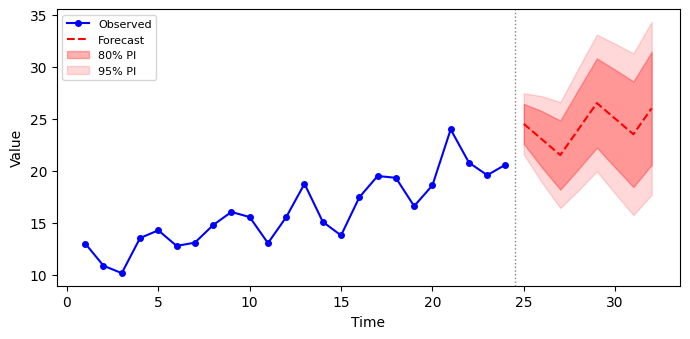

In [ ]:
import numpy as np, matplotlib.pyplot as plt

np.random.seed(42)
t = np.arange(1, 25)
y = 10 + 0.5*t + 2*np.sin(2*np.pi*t/4) + np.random.randn(24)

h = np.arange(25, 33)
mu = 10 + 0.5*h + 2*np.sin(2*np.pi*h/4)
sigma = 1.5 * np.sqrt(h - 24)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t, y, 'b-o', ms=4, label='Observed')
ax.plot(h, mu, 'r--', label='Forecast')
ax.fill_between(h, mu-1.28*sigma, mu+1.28*sigma, alpha=0.3, color='red', label='80% PI')
ax.fill_between(h, mu-1.96*sigma, mu+1.96*sigma, alpha=0.15, color='red', label='95% PI')
ax.axvline(24.5, color='gray', linestyle=':', lw=1)
ax.legend(fontsize=8); ax.set_xlabel('Time'); ax.set_ylabel('Value')
plt.tight_layout(); plt.show()

노이즈가 많이 들어가서 그래프가 별로 안이쁨. forecast 선을 나중에 예측을 해야 함. 안쪽 라인이 80% 바깥쪽 얕은 색 라인이 95% 신뢰구간.

## [Slide 14] 1.8 Installing the Libraries

In [ ]:
# Install (run once in terminal)
# pip install statsforecast neuralforecast hierarchicalforecast
# pip install mlforecast utilsforecast

# Core imports
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    AutoETS,
    AutoARIMA,
    HistoricAverage,
)
from utilsforecast.plotting import plot_series
from utilsforecast.losses import mae, smape, mase

## [Slide 16] 1.9 A First Forecasting Example: Data Structure

In [ ]:
import pandas as pd
import numpy as np

# Nixtlaverse format: long DataFrame with (unique_id, ds, y)
np.random.seed(0)
dates = pd.date_range("2018-01", periods=60, freq="MS")
y = (100 + np.arange(60)*0.5
     + 10*np.sin(2*np.pi*np.arange(60)/12)
     + np.random.randn(60)*3)

df = pd.DataFrame({
    "unique_id": "series_1",
    "ds": dates,
    "y": y
})
print(df.head())
#    unique_id         ds          y
# 0  series_1 2018-01-01  100.15
# 1  series_1 2018-02-01  101.67
# ...

  unique_id         ds           y
0  series_1 2018-01-01  105.292157
1  series_1 2018-02-01  106.700472
2  series_1 2018-03-01  112.596468
3  series_1 2018-04-01  118.222680
4  series_1 2018-05-01  116.262928


## [Slide 18] 1.9 A First Forecasting Example: Fit & Forecast

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, SeasonalNaive

# 1. Instantiate models
models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    SeasonalNaive(season_length=12),
]

# 2. Create StatsForecast object
sf = StatsForecast(models=models, freq="MS", n_jobs=-1)

# 3. Fit and forecast (h = 12 months ahead)
fcst = sf.forecast(df=df, h=12, level=[80, 95])
print(fcst.head())

  unique_id         ds     AutoETS  AutoETS-lo-95  AutoETS-lo-80  \
0  series_1 2023-01-01  130.592260     124.307686     126.482998   
1  series_1 2023-02-01  133.589190     127.304615     129.479927   
2  series_1 2023-03-01  137.738238     131.453662     133.628974   
3  series_1 2023-04-01  141.018045     134.733467     136.908780   
4  series_1 2023-05-01  140.603605     134.319024     136.494339   

   AutoETS-hi-80  AutoETS-hi-95   AutoARIMA  AutoARIMA-lo-95  AutoARIMA-lo-80  \
0     134.701522     136.876834  129.576530       122.831749       125.166355   
1     137.698453     139.873765  133.346081       126.601299       128.935905   
2     141.847502     144.022814  137.054374       130.309593       132.644199   
3     145.127310     147.302623  140.432802       133.688021       136.022627   
4     144.712872     146.888186  139.631676       132.886894       135.221500   

   AutoARIMA-hi-80  AutoARIMA-hi-95  SeasonalNaive  SeasonalNaive-lo-80  \
0       133.986706       136.

## [Slide 20] 1.9 A First Forecasting Example: Evaluate

In [ ]:
from functools import partial
from utilsforecast.losses import mae, mase, smape
from utilsforecast.evaluation import evaluate

# Cross-validation for honest evaluation
cv = sf.cross_validation(
    df=df,
    h=12,
    step_size=6,
    n_windows=3,
)

# Compute error metrics
errors = evaluate(
    cv,
    metrics=[mae, smape, partial(mase, seasonality=12)],
    train_df=df,
)
print(errors)

  unique_id     cutoff metric   AutoETS  AutoARIMA  SeasonalNaive
0  series_1 2020-12-01    mae  3.582462   4.091399       5.972074
1  series_1 2021-06-01    mae  3.184466   3.179745       5.933944
2  series_1 2021-12-01    mae  2.331989   2.452507       5.834467
3  series_1 2020-12-01  smape  0.014964   0.017027       0.025733
4  series_1 2021-06-01  smape  0.013326   0.013348       0.025086
5  series_1 2021-12-01  smape  0.009435   0.009978       0.023896
6  series_1 2020-12-01   mase  0.670688   0.765969       1.118058
7  series_1 2021-06-01   mase  0.597780   0.596894       1.113905
8  series_1 2021-12-01   mase  0.420052   0.441760       1.050939
